# 06 — Bayesian companion analysis

Same experiment, different question. The frequentist analysis in notebook 04 answered 'is the lift significant at alpha=0.05?'. This notebook answers:

1. What is **P(treatment > control | data)**?  
2. What is the **expected loss** of shipping treatment vs holding control?  
3. How does the **posterior on the lift** compare to the frequentist 95% CI?

These are the framings that stakeholders find most actionable. 'p=0.03' is a statement about a hypothetical replication; 'a 96% probability the treatment beats control and an expected gain of 2.4pp if you ship' is a statement about the decision in front of you.

**Model.** Beta(1, 1) uniform prior on each arm's true conversion rate. Conjugate update produces Beta(1 + successes, 1 + failures) posterior per arm. P(theta_t > theta_c) is computed via 100,000 Monte Carlo draws from the two posteriors (a closed-form expression exists but the MC version is more transparent and trivially extends to expected-loss decision rules).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

from src import config
from src.io_utils import load_events, load_manifest
from src.bayes import compare_arms
from src.stats import two_proportion_ztest
from src.viz import _style

FIG_DIR = ROOT / 'reports' / 'figures'

In [2]:
events = load_events(config.EXPERIMENT_EVENTS_PARQUET)
truth = load_manifest(config.GROUND_TRUTH_JSON)
control = events[events.arm == 'control']
treatment = events[events.arm == 'treatment']

sc = int(control.completion.sum()); nc = len(control)
st = int(treatment.completion.sum()); nt = len(treatment)
print(f'control:   {sc} / {nc:,} = {sc/nc:.4f}')
print(f'treatment: {st} / {nt:,} = {st/nt:.4f}')
print(f'true lift (ground truth): {truth["true_lift_pp"]:.2f}pp')

control:   1220 / 24,814 = 0.0492
treatment: 1940 / 25,186 = 0.0770
true lift (ground truth): 2.50pp


## Bayesian comparison

In [3]:
bayes = compare_arms(
    successes_c=sc, n_c=nc,
    successes_t=st, n_t=nt,
    n_samples=100_000, seed=42,
)

print(f'posterior mean (control):   {bayes.mean_c:.4f}')
print(f'posterior mean (treatment): {bayes.mean_t:.4f}')
print()
print(f'P(treatment > control | data): {bayes.prob_t_greater_than_c:.4f}')
print(f'95% credible interval on lift: [{bayes.ci_low_lift*100:+.3f}, {bayes.ci_high_lift*100:+.3f}] pp')
print()
print(f'expected loss of choosing control:   {bayes.expected_loss_choose_c*100:.4f} pp')
print(f'expected loss of choosing treatment: {bayes.expected_loss_choose_t*100:.4f} pp')

posterior mean (control):   0.0492
posterior mean (treatment): 0.0771

P(treatment > control | data): 1.0000
95% credible interval on lift: [+2.357, +3.213] pp

expected loss of choosing control:   2.7854 pp
expected loss of choosing treatment: 0.0000 pp


## Side by side with the frequentist result

In [4]:
freq = two_proportion_ztest(successes_c=sc, n_c=nc, successes_t=st, n_t=nt)

comparison = pd.DataFrame({
    'framing':    ['frequentist', 'bayesian'],
    'point lift (pp)':  [freq.point_estimate * 100, (bayes.mean_t - bayes.mean_c) * 100],
    'interval low (pp)':  [freq.ci_low * 100, bayes.ci_low_lift * 100],
    'interval high (pp)': [freq.ci_high * 100, bayes.ci_high_lift * 100],
    'evidence': [f'p={freq.pvalue:.4g}', f'P(T>C)={bayes.prob_t_greater_than_c:.4f}'],
    'interval semantics': ['95% confidence (frequentist)', '95% credible (bayesian)'],
})
comparison

,framing,point lift (pp),interval low (pp),interval high (pp),evidence,interval semantics
0,frequentist,2.786113,2.360899,3.211326,p=0,95% confidence (frequentist)
1,bayesian,2.785360,2.357078,3.213292,P(T>C)=1.0000,95% credible (bayesian)


Point estimates and intervals are nearly identical (as they should be at this sample size with a flat prior). The interpretation is what differs.

- The frequentist 95% confidence interval says: 'if we re-ran this experiment many times, 95% of the resulting intervals would contain the true lift.' It does NOT say there is a 95% probability the true lift is in this particular interval.
- The Bayesian 95% credible interval says exactly that: 'given the data and the uniform prior, the true lift is in this interval with 95% probability.'

Stakeholders almost always want the second framing. They are asking about the decision in front of them, not about long-run frequencies in a counterfactual replication.

## Posterior densities

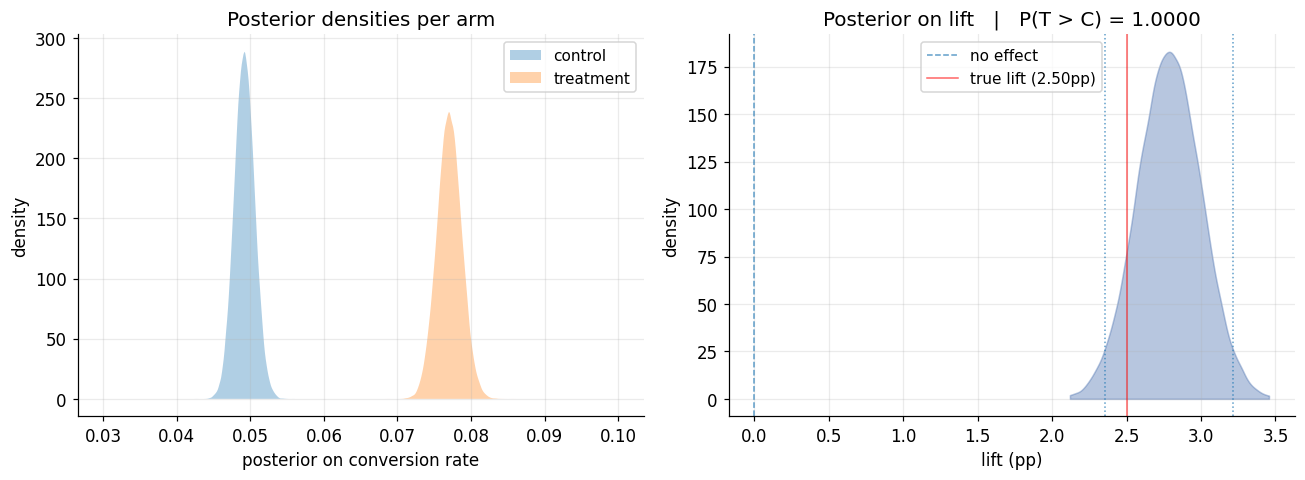

In [5]:
_style()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
kde_c = scipy_stats.gaussian_kde(bayes.samples_c)
kde_t = scipy_stats.gaussian_kde(bayes.samples_t)
x = np.linspace(0.03, 0.10, 600)
ax.fill_between(x, kde_c(x), alpha=0.35, label='control')
ax.fill_between(x, kde_t(x), alpha=0.35, label='treatment')
ax.set_xlabel('posterior on conversion rate')
ax.set_ylabel('density')
ax.set_title('Posterior densities per arm')
ax.legend()

ax = axes[1]
lift_samples = bayes.samples_t - bayes.samples_c
kde_lift = scipy_stats.gaussian_kde(lift_samples)
x = np.linspace(np.quantile(lift_samples, 0.001), np.quantile(lift_samples, 0.999), 600)
ax.fill_between(x * 100, kde_lift(x), alpha=0.4, color='#4c72b0')
ax.axvline(0, linestyle='--', linewidth=1, alpha=0.7, label='no effect')
ax.axvline(bayes.ci_low_lift * 100, linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(bayes.ci_high_lift * 100, linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(truth['true_lift_pp'], color='red', linestyle='-', linewidth=1, alpha=0.6, label=f'true lift ({truth["true_lift_pp"]:.2f}pp)')
ax.set_xlabel('lift (pp)')
ax.set_ylabel('density')
ax.set_title(f'Posterior on lift   |   P(T > C) = {bayes.prob_t_greater_than_c:.4f}')
ax.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / '06_posterior_vs_frequentist.png')
plt.show()

## Operational read

At our sample size with a flat prior, the Bayesian and frequentist answers are computationally indistinguishable. They diverge in two scenarios that matter for real product work.

1. **Informative priors.** If the company has shipped 20 similar cart-page tests, the prior is no longer Beta(1, 1) but something concentrated around the empirical effect-size distribution. This shrinks new results toward the prior and reduces false discoveries at small sample sizes. Frequentist analysis cannot encode this knowledge cleanly.
2. **Small samples.** Below a few hundred users per arm, the normal approximation in the z-test breaks down. The Bayesian posterior is exact for any sample size (the Beta is the conjugate; no approximation).

The decision-theoretic framing also generalizes naturally to non-binary metrics, multi-arm tests, and treatment-heterogeneity questions. For the headline 'is X better?' on a single conversion metric at scale, frequentist and Bayesian give the same answer; the Bayesian framing simply communicates the answer more cleanly.